# Image reconstruction

Import necessary Python packages.

In [1]:
# import packages

import numpy as np
import scipy.io
import matplotlib.pyplot as plt

path_prefix = ""

## Part (c) -1

In [315]:
# ===============================================
# This function pad the image with zeros to ensure every extracted patch is (fh, fw)
#  Don't change it
# ===============================================
def create_design_matrix(image, filter_size):
    h, w = image.shape
    fh, fw = filter_size  # Correctly unpack tuple

    # Pad the image with zeros to ensure every extracted patch is (fh, fw)
    pad_h, pad_w = fh // 2, fw // 2
    padded_image = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)

    X = np.zeros((h * w, fh * fw))

    for i in range(h):
        for j in range(w):
            # Extract patch from the padded image
            patch = padded_image[i:i+fh, j:j+fw]
            X[i*w + j, :] = patch.flatten()
    return X

# ===============================================
# Prepare sparse filter and load the image and filtered image
# Don't change
# ===============================================
input_image = np.load("{}{}".format(path_prefix, 'input_image.npy'))
filtered_image = np.load("{}{}".format(path_prefix, 'filtered_image.npy'))

filter_size = (5, 5)  # 5x5 filter

# Prepare data for regression
X = create_design_matrix(input_image, filter_size)
y = filtered_image.flatten()
# ===============================================


In [ ]:

  # ===============================================
  # Recover filter using OLS
  # Add your code for filter reconstruction here
  # inputs are X,y and  filter_size
  # ===============================================
def recover_filter_ols(X, y, filter_size):
    """ Solve for the filter using the normal equation for OLS """
    #print(len(X))
    #print(len(y))
    #print(filter_size)
    
    # from normal equation w* = (X^TX)^-1X^Ty
    w = np.linalg.inv(X.T @ X) @ (X.T @ y)
    
    w = w.reshape(filter_size)

    return(w)






In [317]:
# ===============================================
# Test your OLS solution
# Don't change it
# ===============================================

# Recover filter using OLS
ols_filter = recover_filter_ols(X, y, filter_size)
# save_filter(ols_filter, 'ols_filter.npy')

print("OLS Filter:")
print(ols_filter)



OLS Filter:
[[-5.04122552e-02 -1.53249548e-01 -1.35426086e-01 -1.09518778e-02
   1.35976399e-02]
 [-1.82636987e-01 -5.02134358e-01 -3.03402670e-01  1.34605107e-01
   1.01130191e-01]
 [-2.34064942e-01 -5.25590108e-01 -7.16907471e-05  5.25334372e-01
   2.34700063e-01]
 [-1.01716741e-01 -1.34322938e-01  3.03167496e-01  5.02421534e-01
   1.82968000e-01]
 [-1.36205674e-02  1.15742775e-02  1.35445455e-01  1.52609099e-01
   5.00781293e-02]]


In [318]:
def visualize_filter(filter, title):
    plt.imshow(filter, cmap='gray')

    plt.title(title)

    plt.show


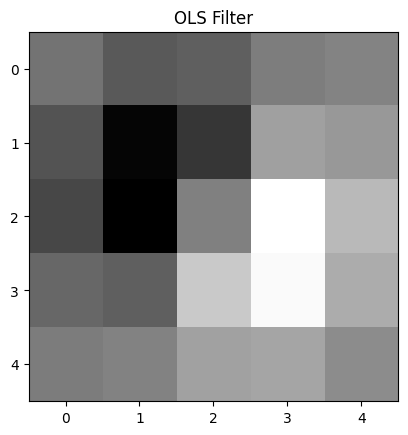

In [319]:
visualize_filter(ols_filter, "OLS Filter")

## Part (c) -2

In [330]:
# ===============================================
# Recover filter using ridge
# Add your code for filter reconstruction here
# inputs are X,y and  filter_size and alpha
# ===============================================
def recover_filter_ridge(X, y, filter_size, lambda_):
  """ Solve for the filter using the normal equation for Ridge regression """

  #print(np.sqrt(len(X)))
  #print(np.matmul(X.transpose(),X))
  #print(len(np.matmul(X.transpose(),X)))

  # from normal equation w* = (X^TX+I*lambda)^-1X^Ty
  w = np.linalg.inv(X.T @ X + np.identity(filter_size[0]*filter_size[1])*lambda_) @ (X.T @ y)
  
  w = w.reshape(filter_size)

  return(w)









In [331]:
# ===============================================
# Test your Ridge solution
# Don't change it
# ===============================================

# Recover filter using Ridge regression
lambda_values = [1.0, 10.0,100,1000]
ridge_filters = {}

for lambda_ in lambda_values:
    ridge_filter = recover_filter_ridge(X, y, filter_size, lambda_)
    ridge_filters[lambda_] = ridge_filter

print("\nRidge Filters for different lambda values:")
for lambda_, filter in ridge_filters.items():
    print(f"\nLambda = {lambda_}")
    print(filter)

# Analyze the effect of Lambda
print("\nEffect of lambda on Ridge regression:")
for lambda_, filter in ridge_filters.items():
    mse = np.mean((filter - ols_filter)**2)
    print(f"Lambda = {lambda_}: MSE from OLS = {mse:.6f}")




Ridge Filters for different lambda values:

Lambda = 1.0
[[-5.04225997e-02 -1.53177253e-01 -1.35337443e-01 -1.09268674e-02
   1.36058706e-02]
 [-1.82543245e-01 -5.01797234e-01 -3.03188839e-01  1.34517766e-01
   1.01068550e-01]
 [-2.33921419e-01 -5.25224531e-01 -7.22442527e-05  5.24968416e-01
   2.34554489e-01]
 [-1.01655507e-01 -1.34234768e-01  3.02953096e-01  5.02083619e-01
   1.82874176e-01]
 [-1.36279418e-02  1.15499115e-02  1.35356219e-01  1.52537503e-01
   5.00911705e-02]]

Lambda = 10.0
[[-5.05125731e-02 -1.52529164e-01 -1.34544948e-01 -1.07044291e-02
   1.36785282e-02]
 [-1.81703643e-01 -4.98783592e-01 -3.01277943e-01  1.33736882e-01
   1.00517348e-01]
 [-2.32637707e-01 -5.21957320e-01 -7.71639008e-05  5.21697840e-01
   2.33252553e-01]
 [-1.01107857e-01 -1.33446542e-01  3.01037162e-01  4.99062933e-01
   1.82033819e-01]
 [-1.36929779e-02  1.13331733e-02  1.34558470e-01  1.51895634e-01
   5.02050876e-02]]

Lambda = 100
[[-5.11364307e-02 -1.46296220e-01 -1.27111128e-01 -8.71892288

## Part D_ image reconstruction

In [332]:
# ===============================================
# This part load the image and set dimesnsions
#  Don't change it
# ===============================================
#  Step 1: Load the saved first row and gradient matrix
first_row = np.load("{}{}".format(path_prefix, 'first_row.npy'))  # Shape: (3*128,)     R_values,      G_valuse,      B_values
Y = np.load("{}{}".format(path_prefix, 'gradient_matrix.npy')).astype(np.int16)

#  Step 2: Define dimensions
n = 128  # Number of rows
w = 128  # Number of columns
c = 3    # Number of color channels (R, G, B)





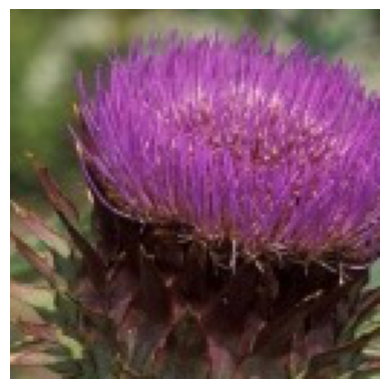

In [333]:
# ===============================================
# Reconstruct the RGB image
# Add your code here , you can use these steps guide or design your self
# ===============================================

# Step 3: Construct A matrix
A = np.zeros((n,w))
for n_ in range(0,n):
    for w_ in range(0,w):
        if w_ <= n_:
            A[n_,w_] = 1

A = np.linalg.inv(A)


# Step 4: Construct full Y matrix
Y_full = np.vstack((first_row_2, Y))


# Step 5: Solve AW = Y using np.linalg.solve

W = np.linalg.solve(A, Y_full)


# Step 6: Deconcatenate W into R, G, and B channels
R_reconstructed = W[:, :w]       # First 128 columns → R channel
G_reconstructed = W[:, w:2*w]     # Next 128 columns → G channel
B_reconstructed = W[:, 2*w:3*w]   # Last 128 columns → B channel


# Step 7: Stack the channels back into an RGB image

reconstructed_img = np.stack((R_reconstructed, G_reconstructed, B_reconstructed), axis=-1)

# Convert to valid image format (No Clipping!)
reconstructed_img = np.round(reconstructed_img).astype(np.int16)

# Display reconstructed images
plt.imshow(reconstructed_img)
plt.axis("off")

plt.show()
